<a href="https://colab.research.google.com/github/Madhav-Engineer/Accident_detection_and_Warning/blob/main/exercise_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision
## Exercise Sheet 2: Image Aquisition, Optics
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1. Madhav Devnarayan (802046)
2.
3.
4.
5.


## Exercise 2.1
### Thin Lenses
Consider a thin lens with a fixed focal length $f$. The light rays coming from an object are focussed by the lens so that the depicted object is in focus at a distance $f_c$ behind the lens. This setting is visualized in the following figure:
<img src="https://drive.google.com/uc?id=1-Wu6CkCwgJkMWUdb20UkFsBjXBvLCJ3V" alt="drawing" width="400"/>

**Draw a sketch** of how $f_c$ would change for an object, which is placed closer to the lens and one placed further away.

## Exercise 2.2
### The influence of the focal length
For a given object we place the image plane at the distance $f_c$ behind the lens, so that the object representation is in focus. How would the image change if the focal length of the lens would increase or decrease?
**Draw a sketch** similar to the one given above, but reduce the focal length. Do not alter $f_c$; what problems occur with the image now?

## Exercise 2.3
### The influence of the aperture
We now add an aperture to the previous model. For simplicity it is placed exactly at the position of the lens. This means that the aperture can be used to decrease the effective diameter of the lens without an influence on the focal length.
In the previous exercise the image plane was placed at the distance $f_c$ corresponding to a focal length $f$ of the lens. Then, the focal length is slightly reduced.
**Alter your sketch from Exercise 2.2.** What influence does the reduction of the aperture have on the image? Which effect can one observe when the diameter of the aperture is very small?

## Exercise 2.4
### Conversion between pixel and camera coordinates
Load data set `ueb24.npy` `(np.load)`.
The image $B(i,j)$ is not a conventional intensity image. Each pixel $p = (x,y,f)^T$ encodes the distance from the focal point of the camera $(0, 0, 0)^T$ to a point in the 3D scene $P = (X, Y, Z)$. $p$ is the projection of $P$ on the image plane. So, the location corresponding to the pixel $p$ from the image matrix $B(i,j)$ will hold the distance $r$ between the point $P$ and the focal point. The image plane containing the pixel $p$, is placed at the distance $f$ from the focal point, parallel to the $XY$ plane.

<img src="https://drive.google.com/uc?id=1TZT2lNjms_CrNBQGC3G3pI3XPZ3iMR3j" alt="drawing" width="400"/>


Write a Python routine that maps each pixel $p$ in $B(i,j)$ to the corresponding point $P = (X,Y,Z)$. Visualize the result in a 3D surface plot `(plt.plot_surface)`. Consider that you are using a camera with focal length $f = 0.008$ meters and a CCD-chip, in which the size of a pixel is $0.00004$ meters. The optical axis intersects the centre of the image matrix, which corresponds to the frame coordinates $(72.5, 88.5)$ on the CCD-chip.

Some helpful commands: `np.arange, np.ones, np.meshgrid`.

In [1]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

Cloning into 'cs4250'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 94 (delta 41), reused 68 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 1.26 MiB | 8.48 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

In [3]:
# load matrix

# define constants

# Create 3 2d-Matrices, each containing the x,y and z value of a vector respecitively.
# Those vectors are supposed to "point at" the image pixels from the centre of focus.
x = np.random.rand(10,10)
y = np.random.rand(10,10)
z = np.random.rand(10,10)

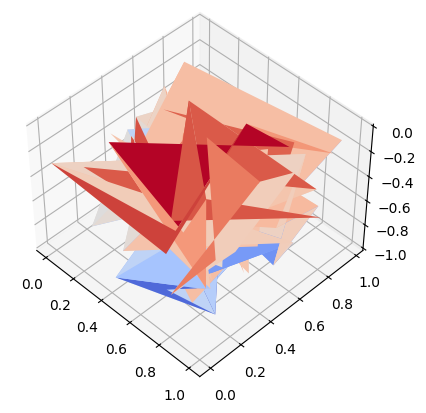

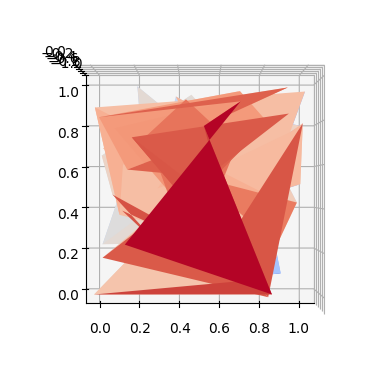

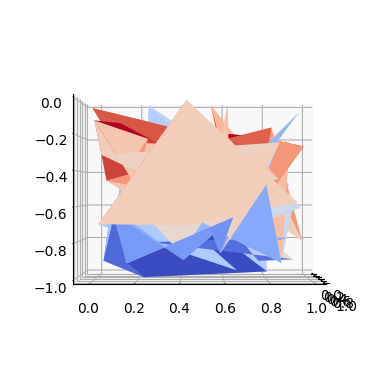

In [4]:
# if you're not using the notebook in Colab, you can use "%matplotlib notebook"
# to create an interactive plot that can be rotated
%matplotlib inline
def plot_3d(x, y, z, elev, azim):
  fig = plt.figure()
  ax = fig.add_subplot(111, projection='3d')
  ax.view_init(elev=elev, azim=azim)
  ax.plot_surface(x,y,-z,cmap=cm.coolwarm)


plot_3d(x, y, z, 45, -45)
plot_3d(x, y, z, 90, -90)
plot_3d(x, y, z, 0, 0)

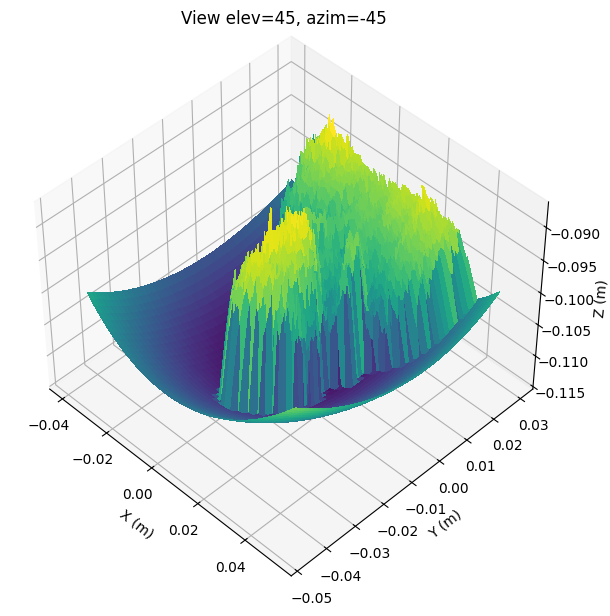

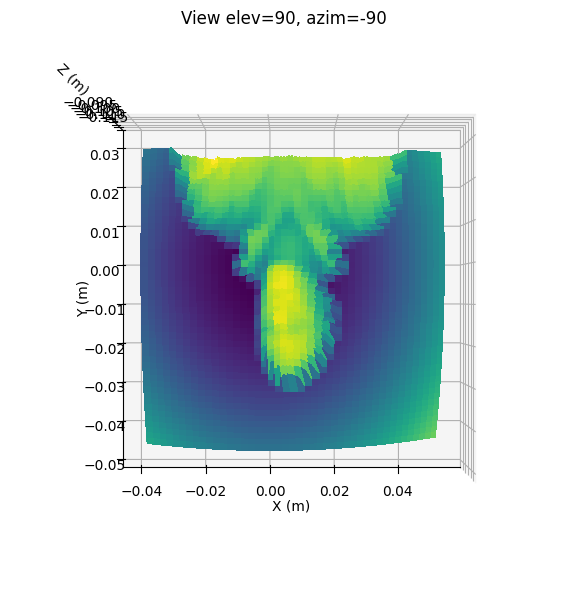

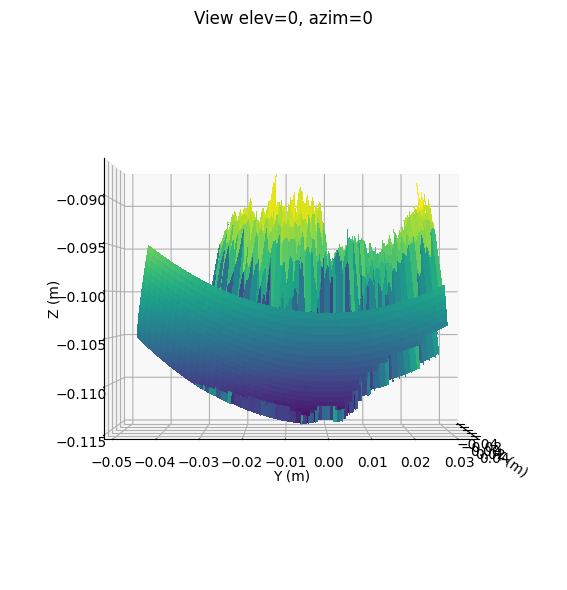

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Load the distance image
B = np.load("/content/cs4250/data/exercise_2/ueb24.npy")  # shape ~ (177, 145)

# --- Constants ---
f = 0.008  # focal length in meters
pixel_size = 0.00004  # size of a pixel in meters
cx, cy = 72.5, 88.5  # optical center in pixel coordinates (image center)

height, width = B.shape

# --- Step 1: Create pixel grid (i, j) ---
# j = column index (x direction), i = row index (y direction)
j_indices = np.arange(width)
i_indices = np.arange(height)
j_grid, i_grid = np.meshgrid(j_indices, i_indices)

# --- Step 2: Convert to physical coordinates in camera plane ---
# Shift origin to optical center and convert pixel indices to meters
x = (j_grid - cx) * pixel_size
y = (i_grid - cy) * pixel_size
z = np.ones_like(x) * f  # All rays lie on the image plane at distance f

# Stack to form direction vectors from the origin to each pixel
directions = np.stack((x, y, z), axis=2)

# Normalize direction vectors
norms = np.linalg.norm(directions, axis=2, keepdims=True)
unit_directions = directions / norms

# --- Step 3: Scale unit direction vectors by B (distance to each point) ---
r = B[..., np.newaxis]  # Shape (H, W, 1) to broadcast properly
P = unit_directions * r  # Shape (H, W, 3)

# --- Step 4: Extract X, Y, Z for plotting ---
X = P[:, :, 0]
Y = P[:, :, 1]
Z = P[:, :, 2]

# --- Plotting ---
def plot_3d(x, y, z, elev, azim):
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x, y, -z, cmap=cm.viridis, linewidth=0, antialiased=False)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.view_init(elev=elev, azim=azim)
    plt.title(f"View elev={elev}, azim={azim}")
    plt.tight_layout()
    plt.show()

# Multiple views
plot_3d(X, Y, Z, elev=45, azim=-45)
plot_3d(X, Y, Z, elev=90, azim=-90)
plot_3d(X, Y, Z, elev=0, azim=0)
